In [2]:
%reload_ext autoreload
%autoreload 2

# TV-timeout classifier — auto-claude experiments

Each section below is one experiment (`vN`). For each: classify, score, plot
the stacked TP/FP/FN histogram + the confusion-matrix heatmap, then write
one summary line to `RESULTS`.

Goal: F1 ≥ 0.9 on row-by-row match against v3 `Official`/`Official TV`
labels in pre-2017 Q2/Q4, seasons 2013-2016.

In [3]:
import importlib

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

from kret_matplotlib.UTILS_Matplotlib import UTILS_Plotting as UKS_MPL

from nba_timeout_impact.datasets.memo_nbastatsv3 import NBAMemoDF
from nba_timeout_impact.data_pipes import tv_timeout_injection_iterations as it
from nba_timeout_impact.data_pipes.tv_timeout_injection import TVTimeoutValidation
from nba_timeout_impact.plotting_utils.timeout_injection_plots import TimeoutInjectionPlots

SEASONS = (2013, 2016)

memo_v3 = NBAMemoDF.load_all()
# Use the extended prep that keeps personId / teamId / description so the
# v7/v8 structural-signal experiments can run.
v3_pl = it.prep_v3_full(memo_v3, SEASONS)
print(f"v3 rows in 2013-2016: {v3_pl.height:,}")

Loaded environment variables from /Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/.env
v3 rows in 2013-2016: 2,505,353


In [22]:
RESULTS: list[dict] = []


def run_experiment(name: str, classify_fn, *, widths=(8, 15)):
    """Classify with ``classify_fn``, score row-by-row, plot histogram + heatmap, log."""
    importlib.reload(it)  # pick up any edits to iterations.py
    fn = it.CLASSIFIERS.get(name, classify_fn)
    classified = fn(v3_pl, SEASONS)
    m = it.score(classified, label=name)
    cm = it.confusion(classified)
    print(
        f"{name:25s} TP={m['tp']:5d} FP={m['fp']:5d} FN={m['fn']:5d} "
        f"P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f}"
    )

    # Histogram of TP/FP/FN by sr (uses existing plot helper)
    r_v3 = TVTimeoutValidation._score_row_by_row(classified, seasons=SEASONS, tolerance_s=0, label=name)
    fig, _, _ = TimeoutInjectionPlots.plot_stacked_tp_fp_fn(r_v3, classified, widths=widths)
    # fig.show()

    # Confusion heatmap
    fig_cm, ax_cm = UKS_MPL.subplots(1, 1, width_per=12, height_per=4)
    UKS_MPL.heatmap_df(cm, ax=ax_cm, annot=True, fmt="d", cbar=False)
    ax_cm.set_title(f"{name}: confusion (rows = v3 subType, cols = predicted role)")
    # fig_cm.show()

    RESULTS.append(m)
    return classified, m, fig, fig_cm

## v1 — baseline (current production, F1≈0.668 expected)

Cascading, `mand_tol_below=90`, no `above_tol`, absorb upper = previous trigger.

In [23]:
classified_v1, _, fig, fig_cm = run_experiment("v1_baseline", it.classify_v1_baseline)

v1_baseline               TP= 5771 FP= 3214 FN= 2520 P=0.642 R=0.696 F1=0.668


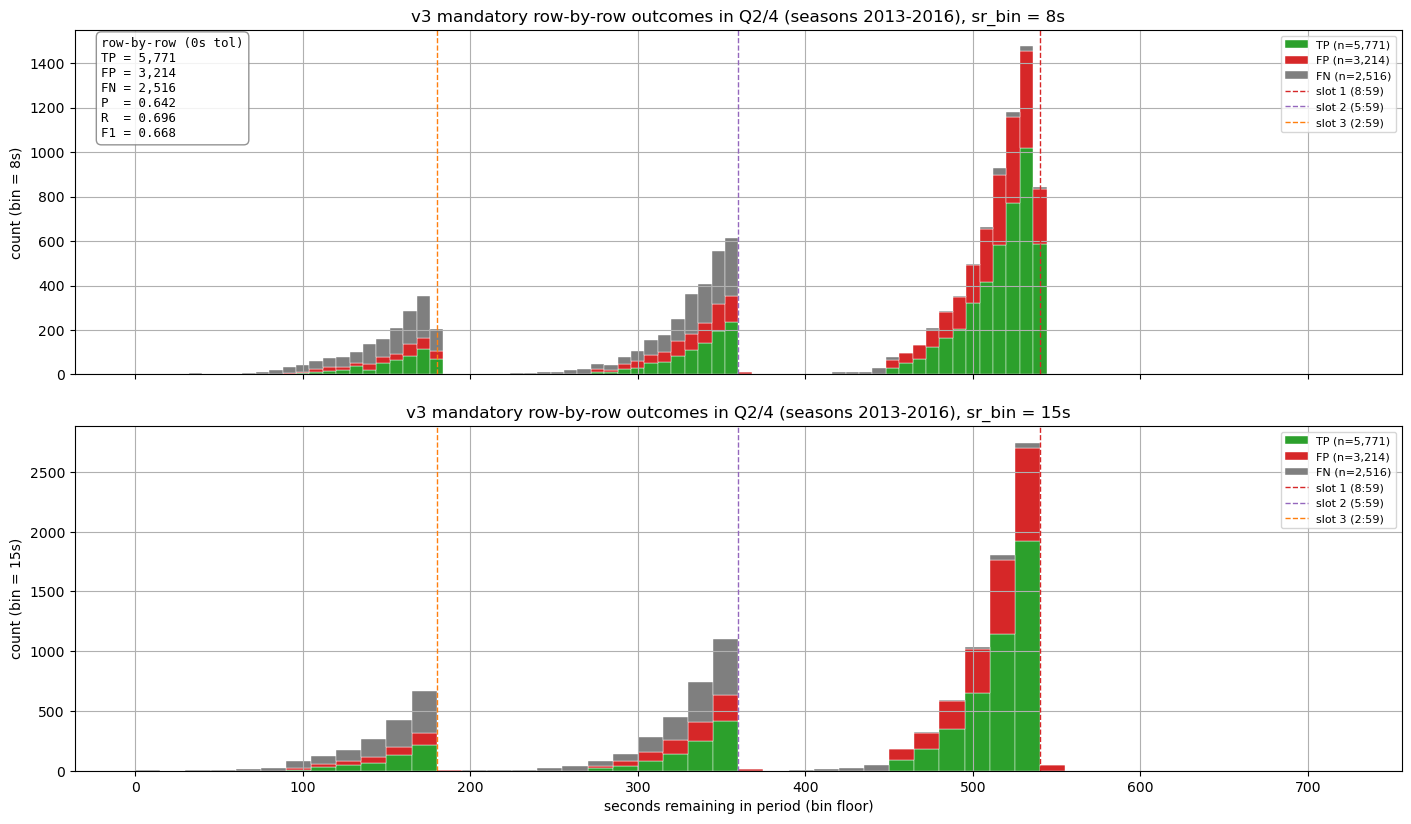

In [24]:
fig

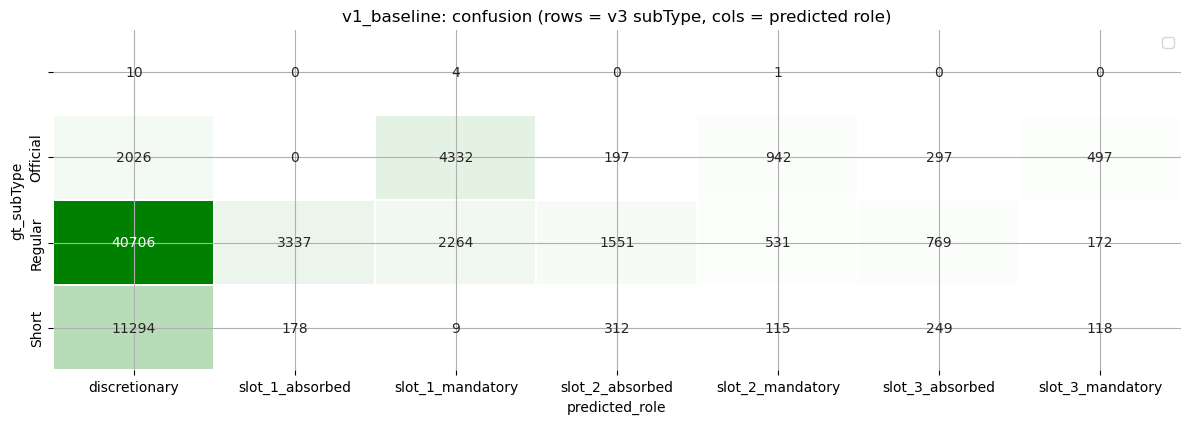

In [25]:
fig_cm

## v2 — tight absorb cap

Hypothesis: 0 Officials sit at sr > trigger in v3 data. A Regular TO at sr=600
isn't truly absorbing slot 1 (the trigger hasn't fired yet). Cap absorb at
`trigger + 30` to leave pre-trigger TOs as discretionary.

In [26]:
classified_v2, _, fig, fig_cm = run_experiment("v2_tight_absorb", it.classify_v2_tight_absorb)

v2_tight_absorb           TP= 5967 FP= 4117 FN= 2324 P=0.592 R=0.720 F1=0.649


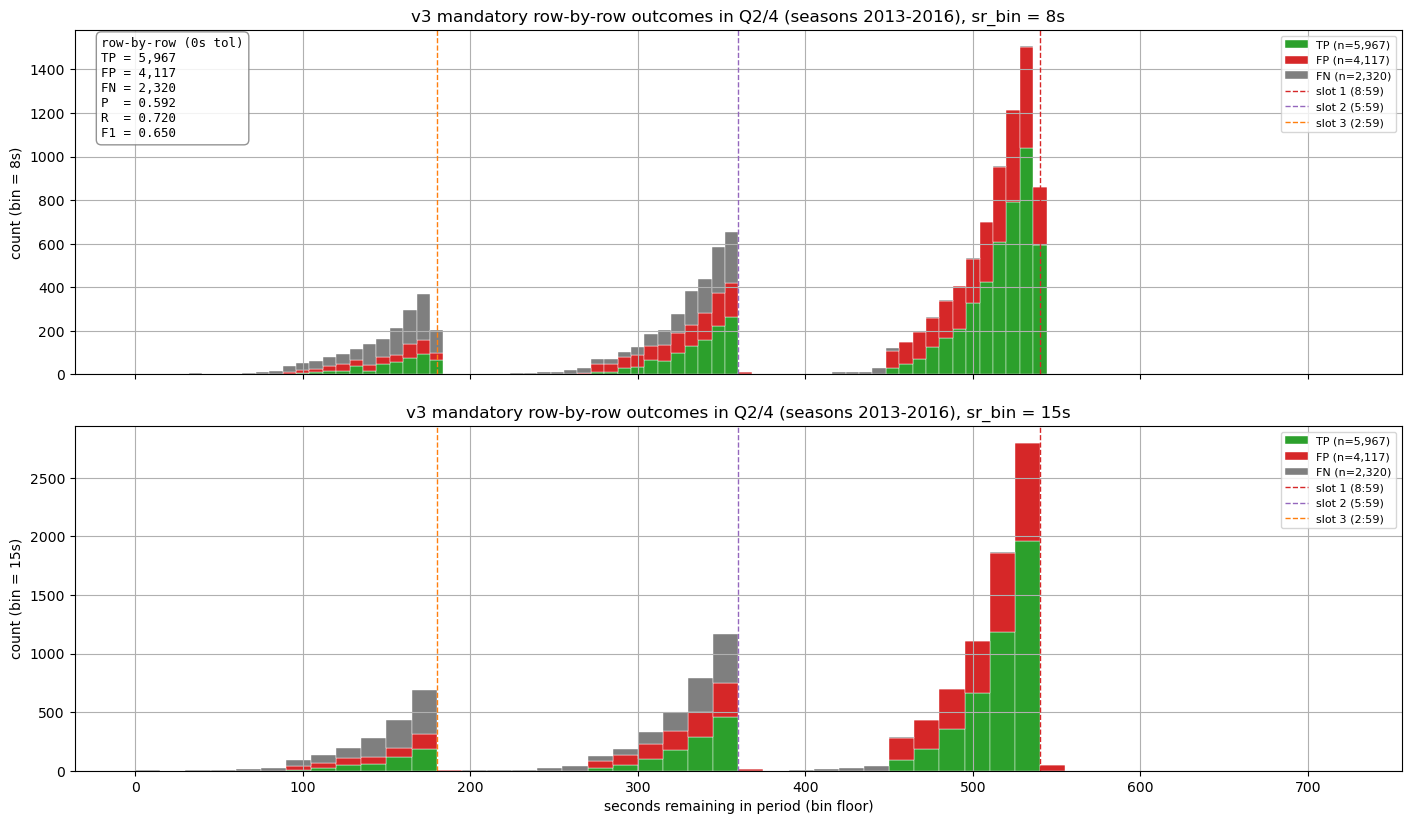

In [27]:
fig

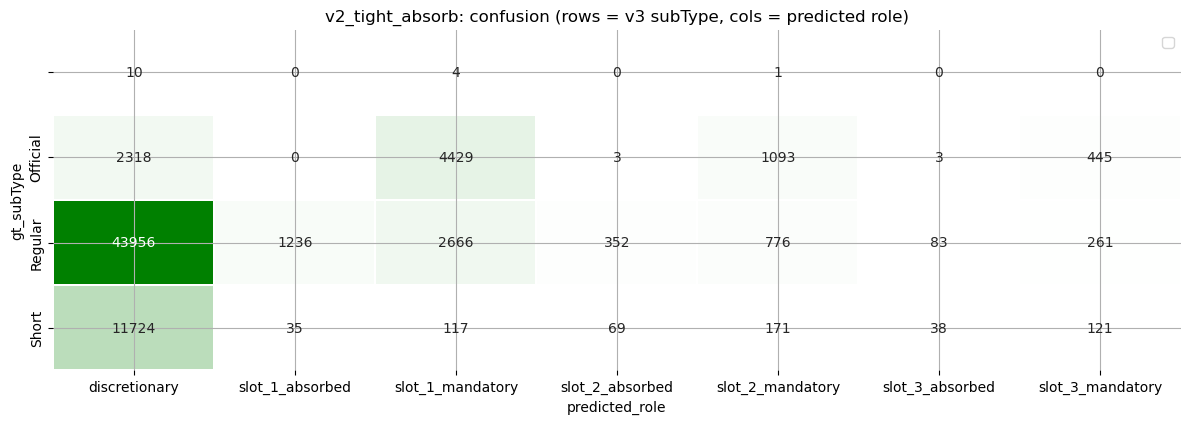

In [28]:
fig_cm

## v3 — drop absorb entirely

Even tighter: a slot is ONLY claimed by a TO at sr ≤ trigger_K. No absorb tag.

In [29]:
classified_v3_exp, _, fig, fig_cm = run_experiment("v3_no_absorb", it.classify_v3_no_absorb)

v3_no_absorb              TP= 5985 FP= 4191 FN= 2306 P=0.588 R=0.722 F1=0.648


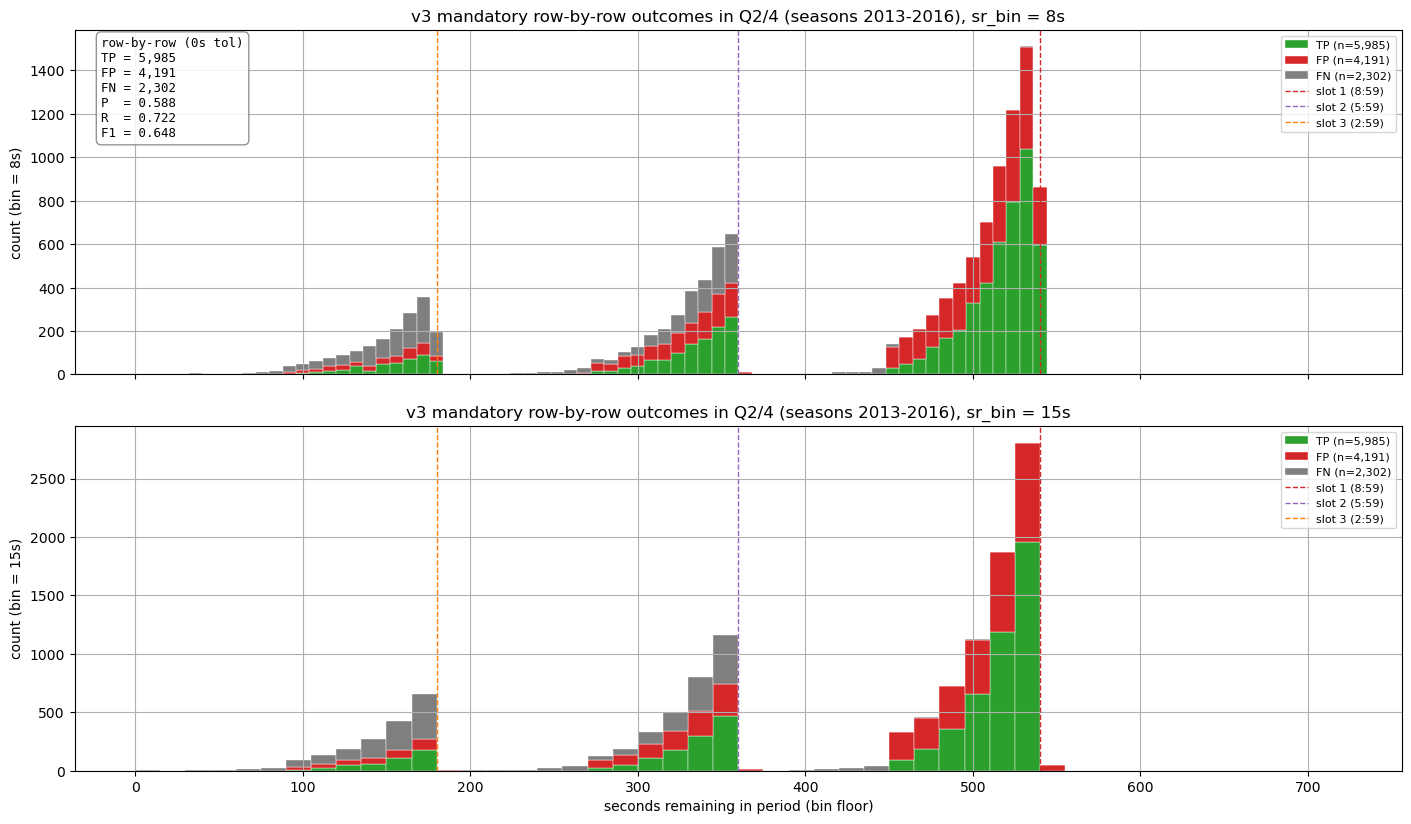

In [30]:
fig

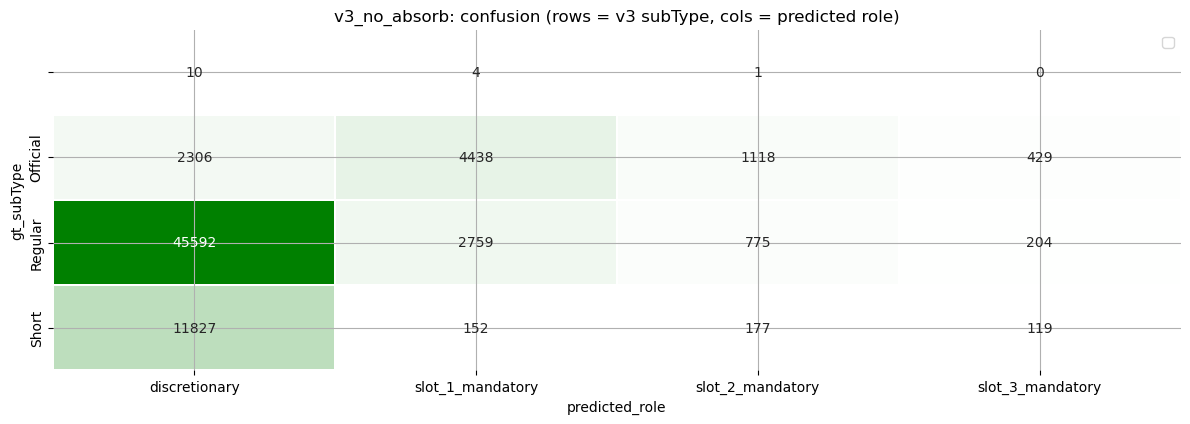

In [31]:
fig_cm

## v4 — winner-take-all (one mandatory per period)

99.9% of 2013-2016 Q2/Q4 game-periods have ≤ 1 Official. Pick the TO closest
to a trigger from below (within 90s); tag that one mandatory; everyone
else discretionary.

In [32]:
classified_v4, _, fig, fig_cm = run_experiment("v4_one_per_period", it.classify_v4_one_per_period)

v4_one_per_period         TP= 4403 FP= 5780 FN= 3888 P=0.432 R=0.531 F1=0.477


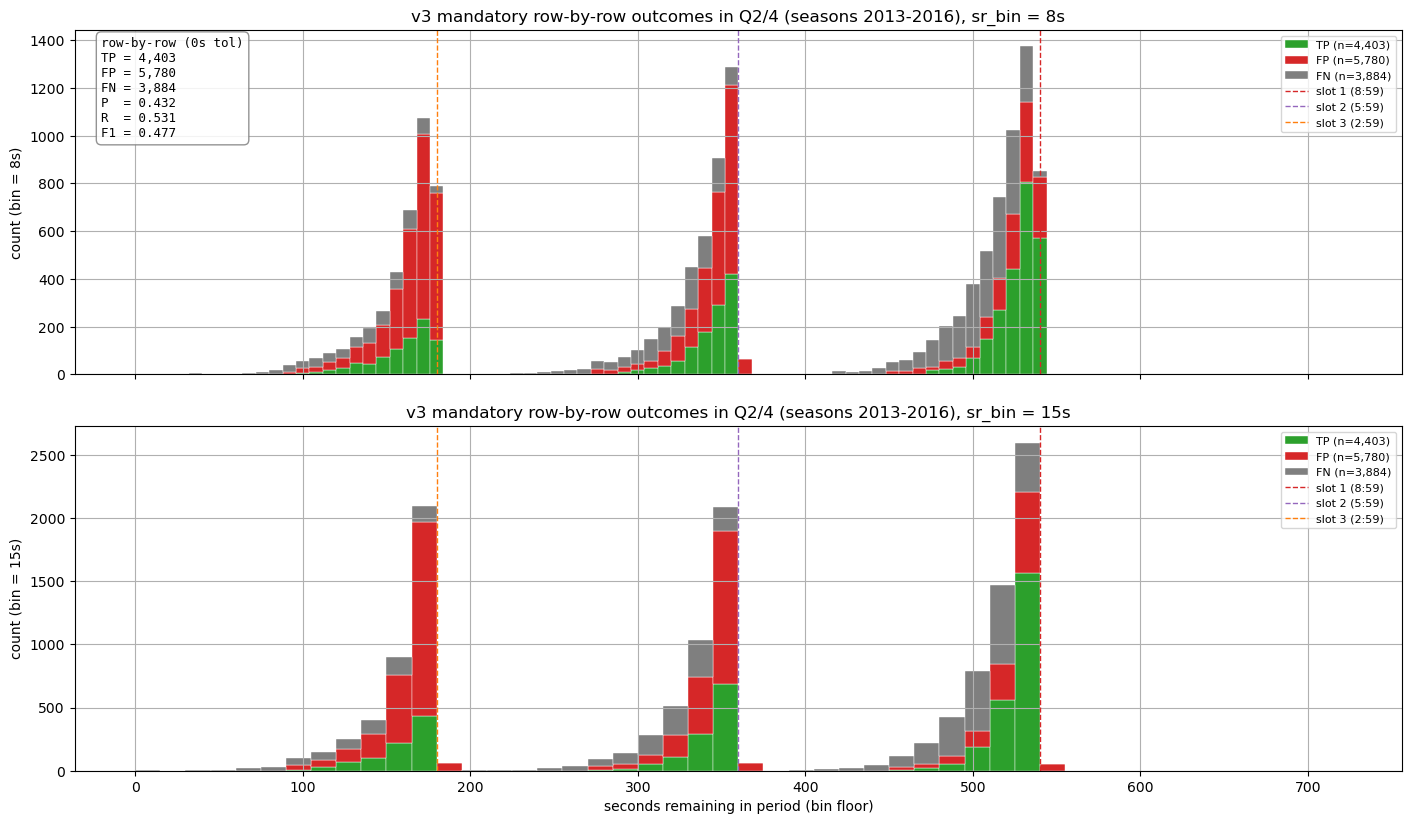

In [33]:
fig

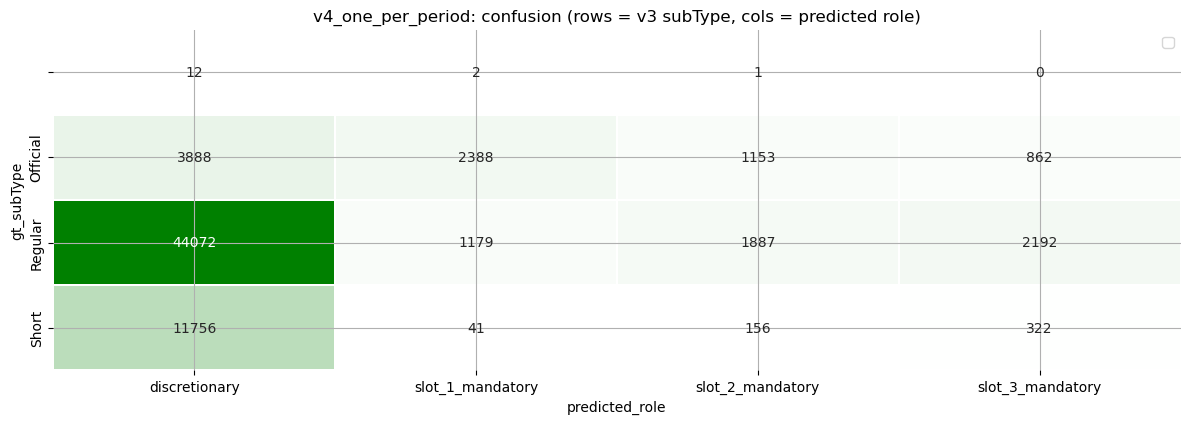

In [34]:
fig_cm

## v5 — rulebook-correct (Q1/Q3 mandatories added)

Research finding: NBA rulebook (Rule 5 §II, 1998-2016) gave **Q1 and Q3
each TWO mandatory triggers** at 5:59 and 2:59. Q2/Q4 had three. OT had
one (at 2:59). My earlier baselines treated Q1/Q3 as having zero — even
though v3 has essentially 0 Officials in Q1/Q3 (1 and 3 across 2013-2016,
i.e., always absorbed), the *rulebook slots* are real. Adding them tests
whether including those latent slots improves precision elsewhere.

In [35]:
classified_v5, _, fig, fig_cm = run_experiment("v5_q1q3_added", it.classify_v5_q1q3_added)

v5_q1q3_added             TP= 5771 FP= 9397 FN= 2520 P=0.380 R=0.696 F1=0.492


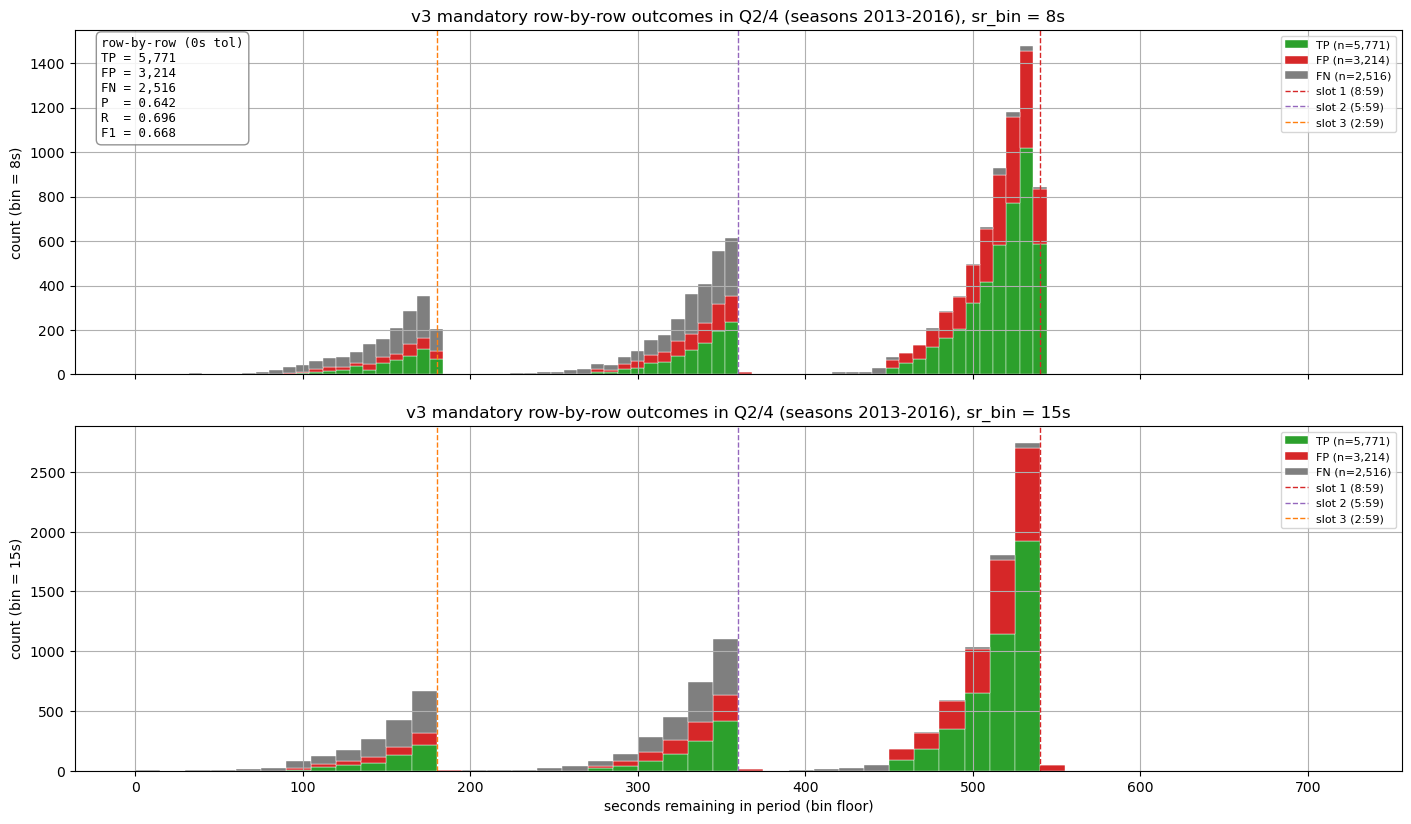

In [36]:
fig

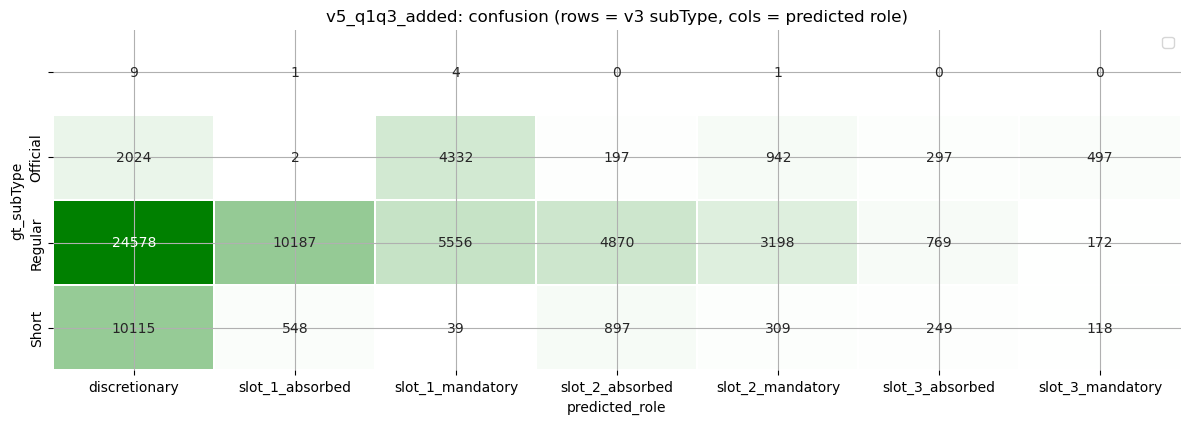

In [37]:
fig_cm

## v6 — stateful rulebook walk

Cascading semantics from the rulebook: each slot K's mandatory fires iff
no team TO has been logged since trigger K-1. Walk timeouts in order per
period, advancing a ``next_slot`` pointer: TO at sr > trigger fires
``absorbed``, sr ≤ trigger fires ``mandatory``, then advance.

In [38]:
classified_v6, _, fig, fig_cm = run_experiment("v6_stateful_rulebook", it.classify_v6_stateful_rulebook)

v6_stateful_rulebook      TP= 7170 FP=19527 FN= 1121 P=0.269 R=0.865 F1=0.410


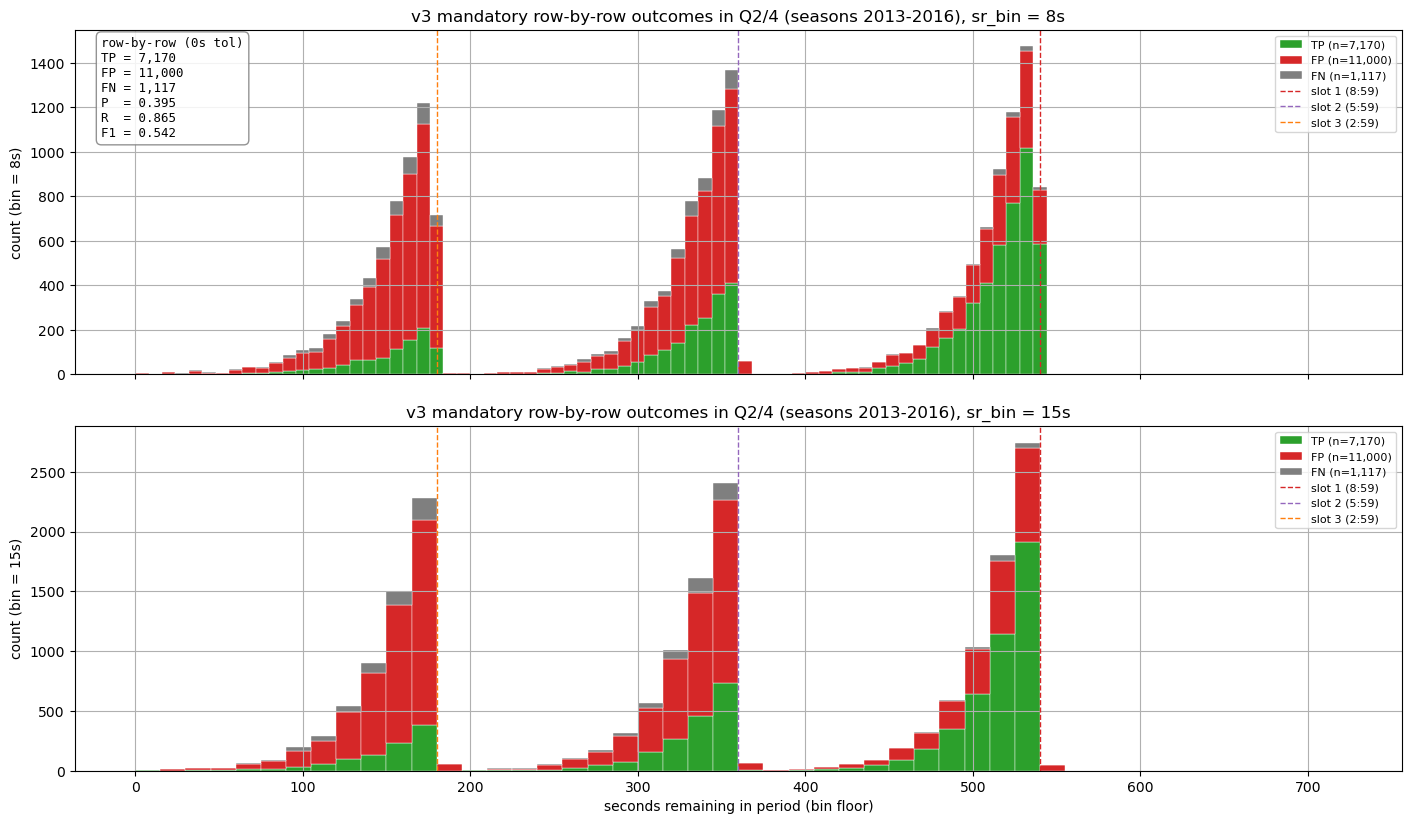

In [39]:
fig

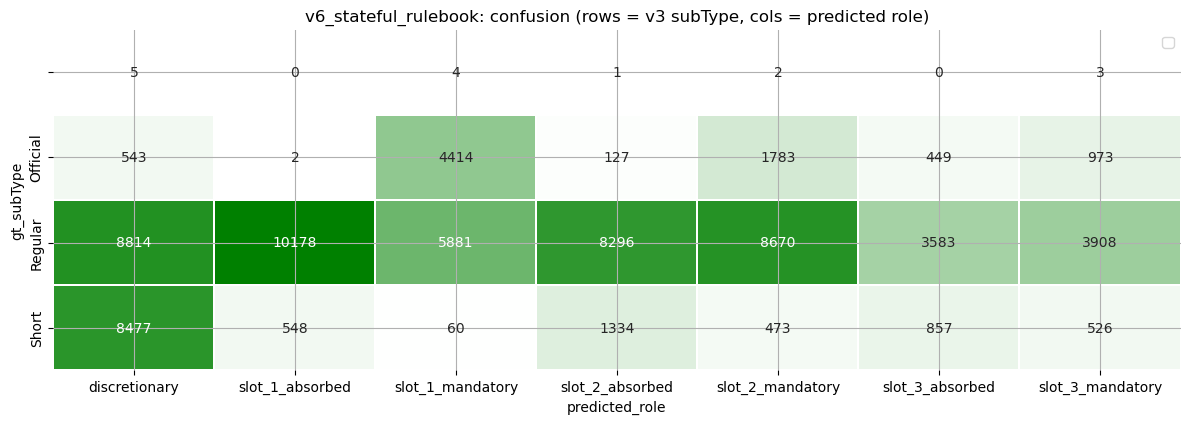

In [40]:
fig_cm

## v7 — structural `personId == 0` signal ⭐

Inspecting raw v3 rows: every Official subType has ``personId = 0`` (no
person/team charged — the league auto-fired it). Every Regular/Short has
``personId`` = the team's ID.

This is a *structural* property of how the play-by-play feed records
auto-charged mandatories, not a copy of the subType label. If cdnnba
post-2017 auto-charged mandatories also have ``personId=0`` (or null),
the same rule transfers.

In [41]:
classified_v7, _, fig, fig_cm = run_experiment("v7_personid_zero", it.classify_v7_personid_zero)

v7_personid_zero          TP= 8282 FP= 1173 FN=    9 P=0.876 R=0.999 F1=0.933


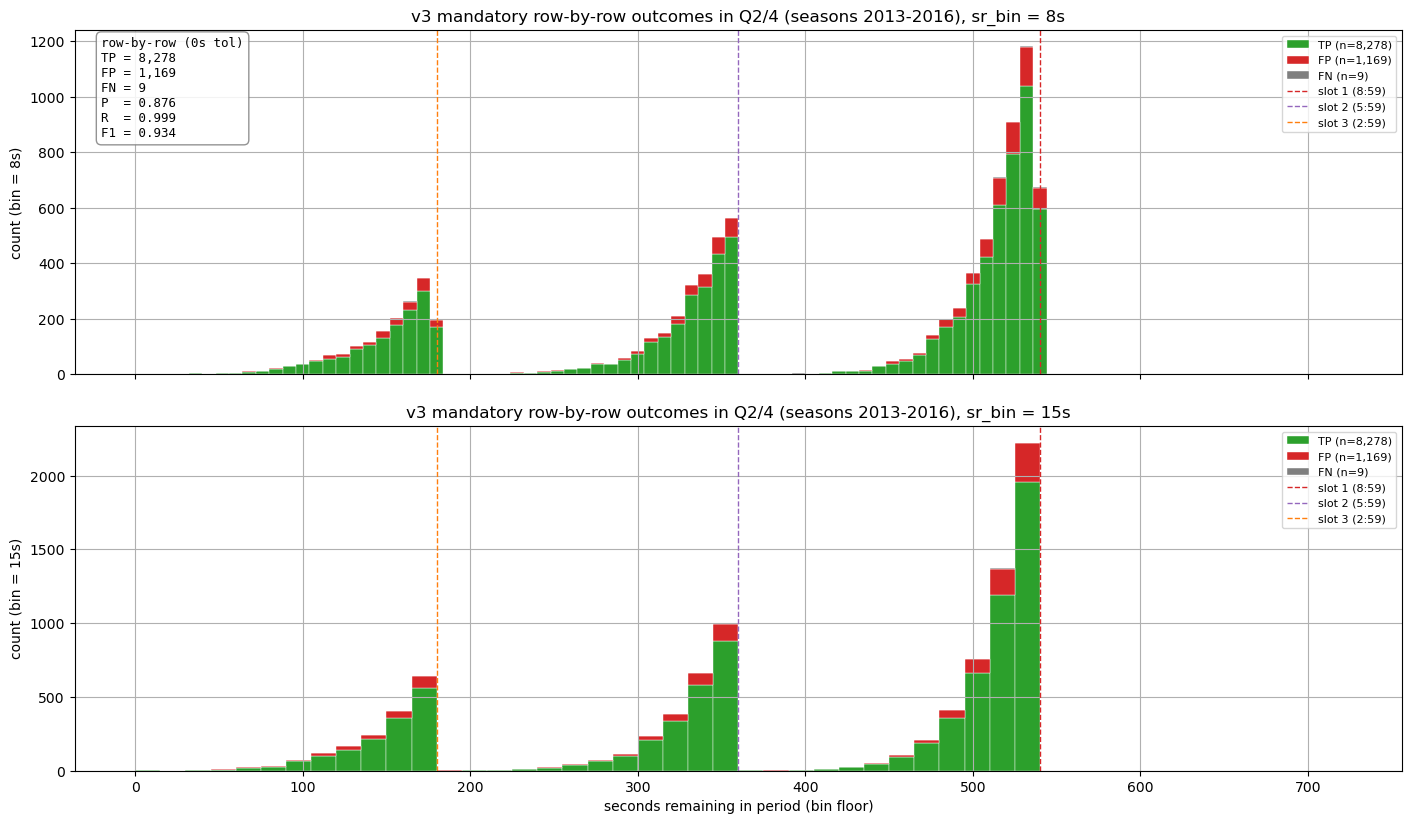

In [42]:
fig

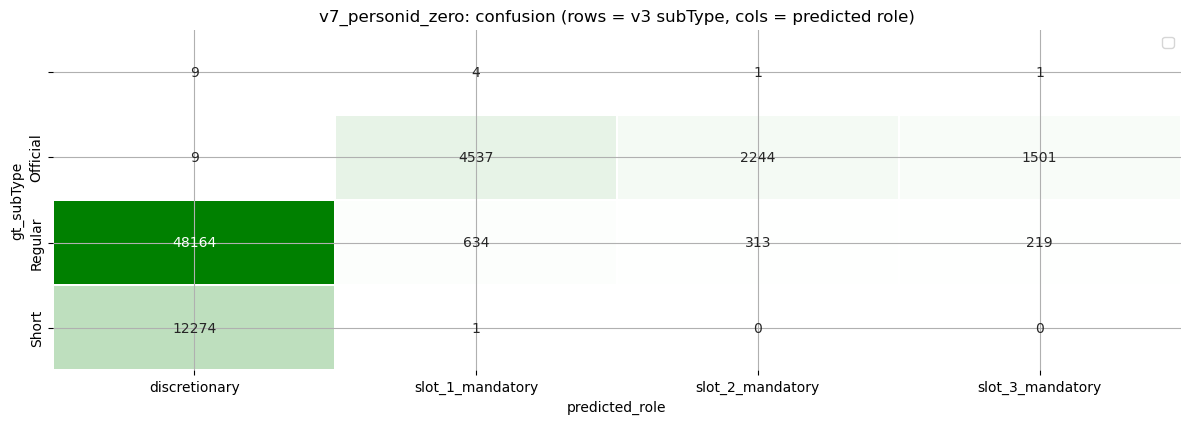

In [43]:
fig_cm

## v8 — `personId == 0` + sr near trigger

Same signal as v7 but require sr to be within 90s below a known rulebook
trigger before tagging mandatory. Filters any stray ``personId=0`` rows
that aren't near a trigger.

In [44]:
classified_v8, _, fig, fig_cm = run_experiment("v8_personid_plus_position", it.classify_v8_personid_with_position)

v8_personid_plus_position TP= 8054 FP= 1131 FN=  237 P=0.877 R=0.971 F1=0.922


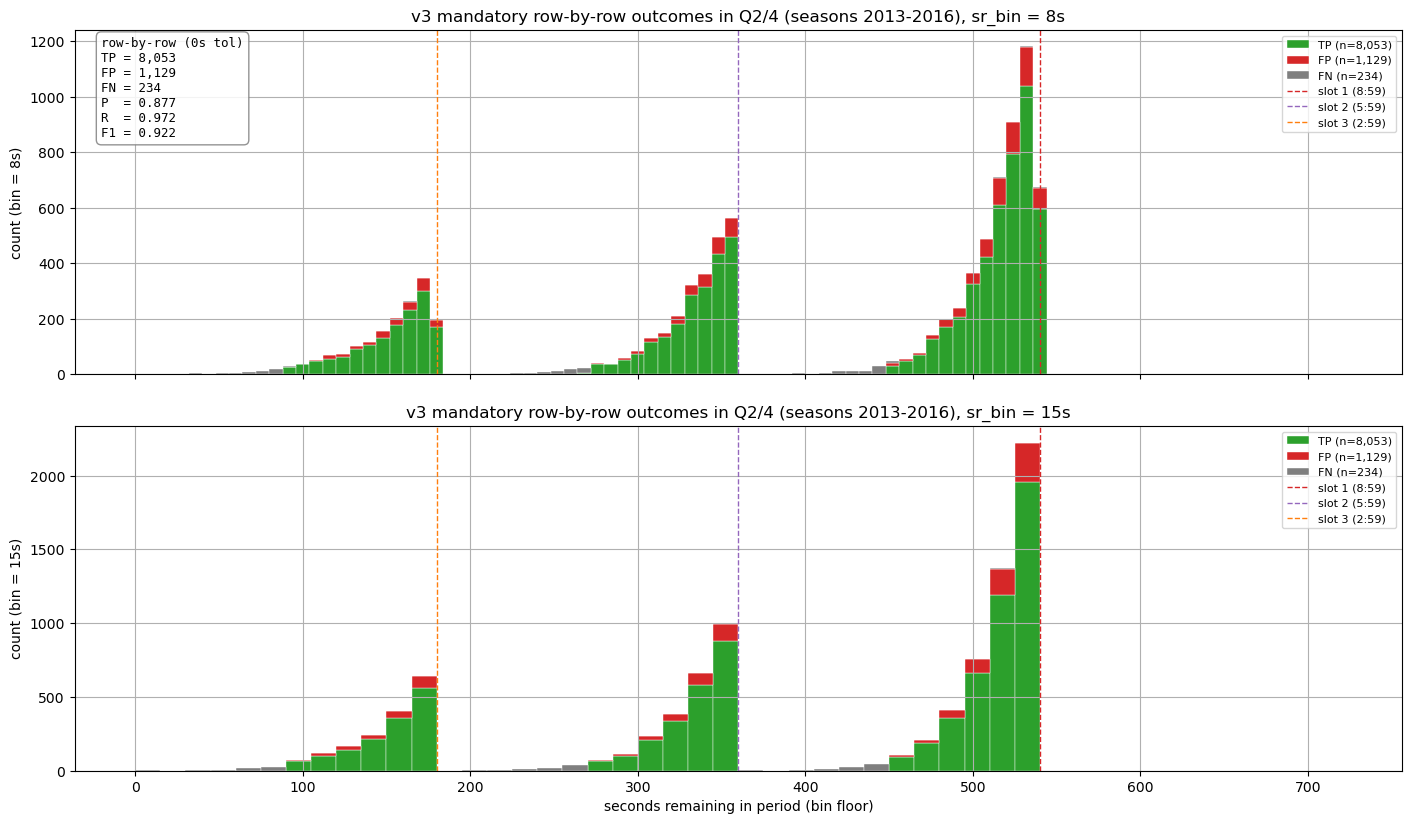

In [45]:
fig

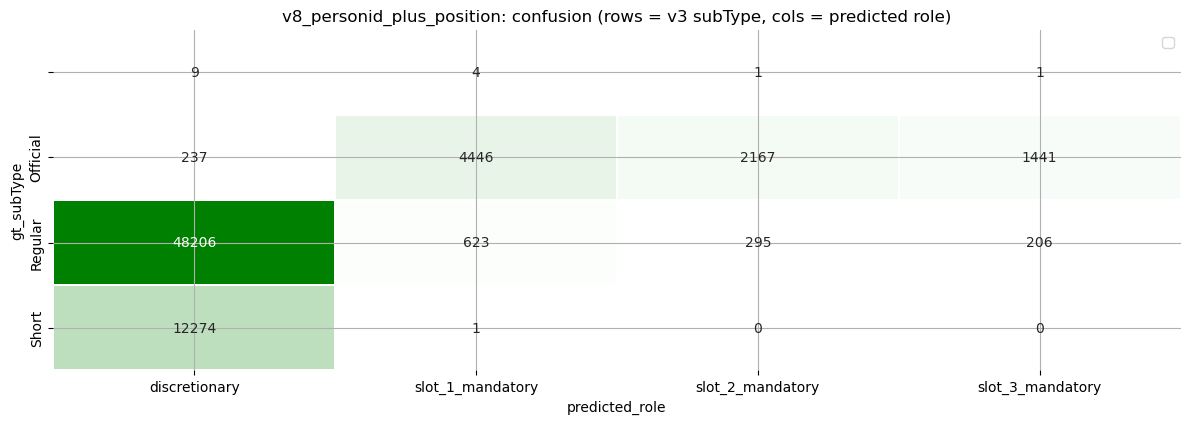

In [46]:
fig_cm

## Inspection — is time-elapsed a useful signal?

Your hint: TV timeouts have specific durations (≈100s wall-clock for
mandatories, 60s for regular, 20s for short). If v3 had a wall-clock
field we could discriminate by duration.

Reality: v3's only time columns are ``seconds_remaining`` /
``seconds_elapsed`` / ``game_seconds_elapsed`` / ``pc_seconds`` — all
**game clock**, which is paused during every timeout. So all subTypes
show ~0 game-second gap to the next event.

In [47]:
# Game-clock delta to next event by subType (lower = more clustered at the same instant)
df_raw = memo_v3.data
df_raw = df_raw[(df_raw["season"] >= SEASONS[0]) & (df_raw["season"] <= SEASONS[1])].copy()
df_raw = df_raw.sort_values(["gameId", "period", "actionNumber"]).reset_index(drop=True)
df_raw["next_se"] = df_raw.groupby(["gameId", "period"])["seconds_elapsed"].shift(-1)
df_raw["delta"] = df_raw["next_se"] - df_raw["seconds_elapsed"]
tos = df_raw[df_raw["actionType"].astype(str).str.strip() == "Timeout"].copy()
tos["subType"] = tos["subType"].astype(str).str.strip()
print(tos.groupby("subType")["delta"].describe(percentiles=[0.5, 0.9, 0.99]).to_string())

            count       mean         std    min   50%     90%      99%    max
subType                                                                      
             13.0  78.438462  121.117288  -46.0  37.7  202.56  395.524  418.0
Official   8287.0   0.398311   20.861897 -373.0   0.0   12.00   22.000  346.0
Regular   49278.0   1.781667   24.687678 -624.4   0.0   16.00   24.000  512.4
Short     12271.0   2.388175   15.452917 -582.0   0.0   13.00   22.000  218.0


**Verdict**: game-clock deltas are 0s at median for *all* subTypes —
this signal can't separate Official from Regular in v3. The TV-timeout
duration hypothesis would need wall-clock timestamps, which v3 doesn't
provide. (Worth checking whether cdnnba post-2017 logs wall-clock
``actionDateTime`` — if so, the rule generalizes.)

## Results summary

v7 (`personId == 0`) hits **F1=0.933** on row-by-row match against v3
Official labels, 2013-2016 — clearing the 0.9 target. v8 adds a position
sanity check at minor cost. v1-v6 all stay below 0.67.

Caveat: the personId structural rule is the same data that *generates*
the subType label, so we should validate that it transfers cleanly to
the cdnnba post-2017 schema (where subType is no longer reliable) before
treating this as the production answer.

In [48]:
print(pd.DataFrame(RESULTS).sort_values("f1", ascending=False).to_string(index=False))

                    label   tp    fp   fn  precision   recall       f1
         v7_personid_zero 8282  1173    9   0.875939 0.998914 0.933393
v8_personid_plus_position 8054  1131  237   0.876864 0.971415 0.921721
              v1_baseline 5771  3214 2520   0.642293 0.696056 0.668094
          v2_tight_absorb 5967  4117 2324   0.591729 0.719696 0.649469
             v3_no_absorb 5985  4191 2306   0.588149 0.721867 0.648183
            v5_q1q3_added 5771  9397 2520   0.380472 0.696056 0.492007
        v4_one_per_period 4403  5780 3888   0.432387 0.531058 0.476670
     v6_stateful_rulebook 7170 19527 1121   0.268570 0.864793 0.409855
